# Customer Churn Prediction
## Introducción

La pérdida de clientes (customer churn) representa uno de los principales desafíos para las empresas que ofrecen servicios por suscripción o contratos de largo plazo. Cada cliente que abandona la compañía implica una reducción en los ingresos y un aumento en los costos asociados a la adquisición de nuevos clientes.

Mediante el análisis de datos y técnicas de Machine Learning es posible identificar patrones de comportamiento asociados con el abandono, permitiendo a la empresa implementar estrategias de retención antes de que el cliente decida cancelar el servicio.

En este proyecto se desarrolla un modelo predictivo capaz de estimar la probabilidad de churn a partir de las características de cada cliente, utilizando un conjunto de datos de una empresa de telecomunicaciones.

### Dataset Description

El conjunto de datos contiene información demográfica, características de los servicios contratados, tipo de contrato, método de pago, cargos mensuales y el historial del cliente. La variable objetivo es Churn, que indica si el cliente abandonó o no el servicio.

| **Atributo**         | **Descripción**                                                                                                                                             |
| -------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **customerID**       | Identificador único del cliente.                                                                                                                            |
| **gender**           | Género del cliente (masculino o femenino).                                                                                                                  |
| **SeniorCitizen**    | Indica si el cliente es un adulto mayor (Sí/No).                                                                                                            |
| **Partner**          | Indica si el cliente tiene pareja (Sí/No).                                                                                                                  |
| **Dependents**       | Indica si el cliente tiene personas a cargo (Sí/No).                                                                                                        |
| **tenure**           | Cantidad de meses que el cliente ha permanecido en la empresa.                                                                                              |
| **PhoneService**     | Indica si el cliente cuenta con servicio telefónico (Sí/No).                                                                                                |
| **MultipleLines**    | Indica si el cliente posee múltiples líneas telefónicas (Sí, No o Sin servicio telefónico).                                                                 |
| **InternetService**  | Tipo de servicio de Internet contratado (DSL, Fibra óptica o Sin servicio).                                                                                 |
| **OnlineSecurity**   | Indica si el cliente posee el servicio de seguridad en línea (Sí, No o Sin servicio de Internet).                                                           |
| **OnlineBackup**     | Indica si el cliente cuenta con servicio de respaldo en línea (Sí, No o Sin servicio de Internet).                                                          |
| **DeviceProtection** | Indica si el cliente posee protección para sus dispositivos (Sí, No o Sin servicio de Internet).                                                            |
| **TechSupport**      | Indica si el cliente dispone de soporte técnico (Sí, No o Sin servicio de Internet).                                                                        |
| **StreamingTV**      | Indica si el cliente utiliza el servicio de televisión por streaming (Sí, No o Sin servicio de Internet).                                                   |
| **StreamingMovies**  | Indica si el cliente utiliza el servicio de películas por streaming (Sí, No o Sin servicio de Internet).                                                    |
| **Contract**         | Tipo de contrato del cliente (Mensual, Un año o Dos años).                                                                                                  |
| **PaperlessBilling** | Indica si el cliente utiliza facturación electrónica (Sí/No).                                                                                               |
| **PaymentMethod**    | Método de pago utilizado por el cliente (Cheque electrónico, Cheque enviado por correo, Transferencia bancaria automática o Tarjeta de crédito automática). |
| **MonthlyCharges**   | Importe cobrado mensualmente al cliente.                                                                                                                    |
| **TotalCharges**     | Importe total cobrado al cliente desde el inicio del servicio.                                                                                              |
| **Churn**            | Variable objetivo que indica si el cliente abandonó la empresa (Sí/No).                                                                                     |


### Objetivo del Proyecto

Desarrollar un modelo de Machine Learning capaz de predecir si un cliente abandonará el servicio (Customer Churn) a partir de sus características demográficas, los servicios contratados y la información de facturación.

Además, identificar las variables que presentan una mayor influencia en la probabilidad de abandono, proporcionando información que pueda contribuir al diseño de estrategias de retención de clientes.

### Hipótesis Principal

Se plantea que los clientes con contratos mensuales (Month-to-month), menor antigüedad en la empresa (tenure) y cargos mensuales más elevados (MonthlyCharges) presentan una mayor probabilidad de abandonar el servicio en comparación con aquellos que poseen contratos de mayor duración y una relación más estable con la compañía.

### Carga de Datos y librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### maching learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


In [2]:
data_df = pd.read_csv("../data/raw/Customer-Churn.csv")

customer_df = data_df.copy()

### Comprensión de los datos

Antes de iniciar el proceso de limpieza y análisis, es fundamental comprender la estructura del conjunto de datos. En esta etapa se realiza una exploración inicial para identificar el tamaño del dataset, las variables disponibles, sus tipos de datos y la información que contienen.

Este primer análisis permite detectar posibles inconsistencias, reconocer la variable objetivo del proyecto y establecer una base sólida para las etapas posteriores de evaluación de calidad, análisis exploratorio y preparación de los datos para Machine Learning.

In [3]:
customer_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
customer_df.shape

(7043, 21)

In [5]:
customer_df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [6]:
customer_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

#### Conclusion

El conjunto de datos está compuesto por 7.043 registros y 21 variables, que incluyen información demográfica, servicios contratados, características de facturación y la variable objetivo Churn.

En esta etapa también se identificó que la mayoría de las variables son categóricas, mientras que únicamente tenure, SeniorCitizen y MonthlyCharges se encuentran representadas como variables numéricas. Además, se observó que TotalCharges fue importada como texto, lo que indica la necesidad de revisar su contenido durante la etapa de evaluación de la calidad de los datos.

### Limpieza y transformación de datos

Una vez comprendida la estructura del conjunto de datos, se llevó a cabo el proceso de limpieza y transformación con el objetivo de garantizar la calidad de la información antes del análisis exploratorio y del entrenamiento de los modelos de Machine Learning.

Durante esta etapa se verificó la consistencia de los datos mediante la revisión de valores únicos, categorías, valores nulos, duplicados y posibles errores de tipado. Además, se realizaron las transformaciones necesarias para mejorar la representación de las variables, corregir inconsistencias y asegurar que cada columna tuviera el tipo de dato más adecuado para su posterior análisis.

In [7]:
for column in customer_df.columns:
    print(f"la columna {column} cuenta con : {customer_df[column].nunique()}")
    print(f"{customer_df[column].unique()}\n\n")

la columna customerID cuenta con : 7043
<StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7043, dtype: str


la columna gender cuenta con : 2
<StringArray>
['Female', 'Male']
Length: 2, dtype: str


la columna SeniorCitizen cuenta con : 2
[0 1]


la columna Partner cuenta con : 2
<StringArray>
['Yes', 'No']
Length: 2, dtype: str


la columna Dependents cuenta con : 2
<StringArray>
['No', 'Yes']
Length: 2, dtype: str


la columna tenure cuenta con : 73
[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]


la columna PhoneService cuenta con : 2
<StringArray>
['No

In [8]:
for columna in customer_df.columns:
    duplicados = customer_df.duplicated().sum()
    nulls = customer_df[columna].isna().sum()
    print(f"la columna : {columna} tiene {duplicados} duplicados y {nulls} nulos ")

la columna : customerID tiene 0 duplicados y 0 nulos 
la columna : gender tiene 0 duplicados y 0 nulos 
la columna : SeniorCitizen tiene 0 duplicados y 0 nulos 
la columna : Partner tiene 0 duplicados y 0 nulos 
la columna : Dependents tiene 0 duplicados y 0 nulos 
la columna : tenure tiene 0 duplicados y 0 nulos 
la columna : PhoneService tiene 0 duplicados y 0 nulos 
la columna : MultipleLines tiene 0 duplicados y 0 nulos 
la columna : InternetService tiene 0 duplicados y 0 nulos 
la columna : OnlineSecurity tiene 0 duplicados y 0 nulos 
la columna : OnlineBackup tiene 0 duplicados y 0 nulos 
la columna : DeviceProtection tiene 0 duplicados y 0 nulos 
la columna : TechSupport tiene 0 duplicados y 0 nulos 
la columna : StreamingTV tiene 0 duplicados y 0 nulos 
la columna : StreamingMovies tiene 0 duplicados y 0 nulos 
la columna : Contract tiene 0 duplicados y 0 nulos 
la columna : PaperlessBilling tiene 0 duplicados y 0 nulos 
la columna : PaymentMethod tiene 0 duplicados y 0 nulos 


In [9]:
for column in customer_df.select_dtypes(include=["object","string"]).columns :
    empty = customer_df[column].str.strip().eq("").sum()
    if empty > 0:
        print(f"la columna {column} cuenta con : {empty}, valores vacios vacias")
    

la columna TotalCharges cuenta con : 11, valores vacios vacias


In [10]:
CantidadVacia = customer_df["TotalCharges"].str.strip().eq("").sum()
Total = customer_df["TotalCharges"].shape[0]

print(f"el porcentaje de datos vacios son :{((CantidadVacia/Total)*100).round(2)} %")

el porcentaje de datos vacios son :0.16 %


In [11]:
customer_df.loc[
    customer_df["TotalCharges"].str.strip().eq(""),
    ["customerID","tenure","MonthlyCharges","TotalCharges", "Contract", "Churn"]
]

,customerID,tenure,MonthlyCharges,TotalCharges,Contract,Churn
488,4472-LVYGI,0,52.55,,Two year,No
753,3115-CZMZD,0,20.25,,Two year,No
936,5709-LVOEQ,0,80.85,,Two year,No
1082,4367-NUYAO,0,25.75,,Two year,No
1340,1371-DWPAZ,0,56.05,,Two year,No
3331,7644-OMVMY,0,19.85,,Two year,No
3826,3213-VVOLG,0,25.35,,Two year,No
4380,2520-SGTTA,0,20.00,,Two year,No
5218,2923-ARZLG,0,19.70,,One year,No
6670,4075-WKNIU,0,73.35,,Two year,No


In [12]:
customer_df["TotalCharges"] = customer_df["TotalCharges"].replace(" ", np.nan)
customer_df["TotalCharges"].isna().sum()

np.int64(11)

In [13]:
customer_df["TotalCharges"] = customer_df["TotalCharges"].astype(float)
customer_df["TotalCharges"].dtype

dtype('float64')

In [14]:
customer_df = customer_df.dropna(subset=["TotalCharges"])
customer_df = customer_df.reset_index(drop=True)
customer_df["TotalCharges"].isna().sum()

np.int64(0)

In [15]:
customer_df["SeniorCitizen"] = customer_df["SeniorCitizen"].replace({1:"Yes",0:"No"})


In [16]:
columnas_NIS = ["OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies"]

for columna in columnas_NIS:
    customer_df[columna] = customer_df[columna].replace({"No internet service":"No"})

In [17]:
columnas_NIS = ["OnlineSecurity","OnlineBackup","DeviceProtection","TechSupport","StreamingTV","StreamingMovies"]

for columna in columnas_NIS:
    empty = (customer_df[columna] == "No internet service").sum()
    print(f"{empty}")

0
0
0
0
0
0


In [18]:
Columa_Categoria = ["gender", "SeniorCitizen", "Partner", "Dependents", "PhoneService", "InternetService", 
                    "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", 
                    "StreamingMovies", "Contract", "PaperlessBilling", "PaymentMethod", "Churn"]
for column in Columa_Categoria:
    customer_df[column] = customer_df[column].astype("category")

customer_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7032 non-null   str     
 1   gender            7032 non-null   category
 2   SeniorCitizen     7032 non-null   category
 3   Partner           7032 non-null   category
 4   Dependents        7032 non-null   category
 5   tenure            7032 non-null   int64   
 6   PhoneService      7032 non-null   category
 7   MultipleLines     7032 non-null   str     
 8   InternetService   7032 non-null   category
 9   OnlineSecurity    7032 non-null   category
 10  OnlineBackup      7032 non-null   category
 11  DeviceProtection  7032 non-null   category
 12  TechSupport       7032 non-null   category
 13  StreamingTV       7032 non-null   category
 14  StreamingMovies   7032 non-null   category
 15  Contract          7032 non-null   category
 16  PaperlessBilling  7032 non-null   c

#### Conclusion

La evaluación de la calidad de los datos permitió comprobar que el conjunto de datos no presentaba valores nulos, registros duplicados ni errores de tipado en las variables categóricas. Sin embargo, se identificaron 11 registros con valores vacíos en la columna TotalCharges, representando únicamente el 0,16 % del total del dataset.

Tras analizar estos registros, se observó que correspondían a clientes con una antigüedad (tenure) igual a 0 meses, es decir, clientes recientemente incorporados que aún no habían acumulado cargos totales. Debido a su baja representación y a que no era posible imputar un valor coherente, se decidió eliminarlos del conjunto de datos.

Finalmente, se realizaron las transformaciones necesarias para optimizar el análisis y la preparación de los datos, incluyendo la conversión de tipos de datos, la unificación de categorías (por ejemplo, reemplazando "No internet service" por "No") y la estandarización de variables como SeniorCitizen, que pasó de una representación numérica (0/1) a una categórica (Yes/No). Estas modificaciones permitieron obtener un conjunto de datos más consistente, interpretable y adecuado para las etapas posteriores del proyecto.

### Análisis exploratorio

Una vez obtenido un conjunto de datos limpio y consistente, se realizó el análisis exploratorio con el objetivo de identificar patrones y relaciones entre las características de los clientes y la variable objetivo Churn.

Para ello, se analizaron tanto las variables categóricas como las numéricas. En las variables categóricas se comparó la distribución porcentual de cada categoría entre los clientes que permanecieron en la empresa (No Churn) y aquellos que abandonaron el servicio (Yes Churn). Por otro lado, para las variables numéricas se utilizaron estadísticas descriptivas y diagramas de caja (boxplots) con el fin de comparar su comportamiento entre ambos grupos e identificar diferencias relevantes.

Este análisis permite comprender qué características presentan una mayor asociación con el abandono del servicio y proporciona una base sólida para la etapa de modelado predictivo.

In [19]:
customer_df[["tenure","MonthlyCharges","TotalCharges"]].describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


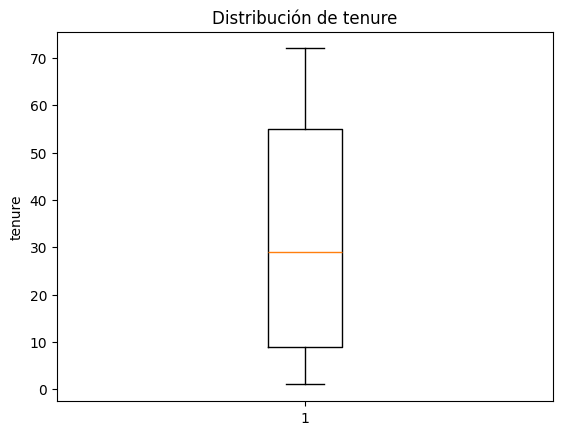

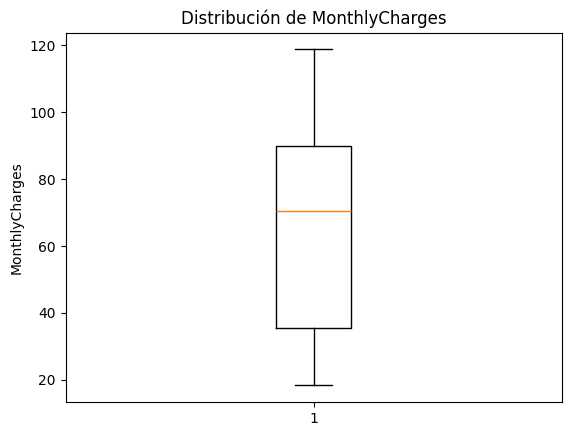

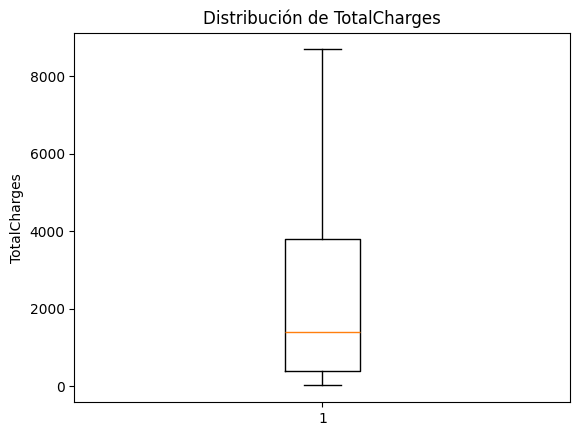

In [20]:
columnas_num = ["tenure","MonthlyCharges","TotalCharges"]

def analisis_columnas(df, columna):

    plt.Figure(figsize=(6,4))
    plt.boxplot(df[columna].dropna(), orientation="vertical")
    plt.title(f"Distribución de {columna}")
    plt.ylabel(f"{columna}")
    plt.show()

for columna in columnas_num:
    analisis_columnas(customer_df, columna)

La columna gender presenta : gender
Female    3483
Male      3549
Name: count, dtype: int64


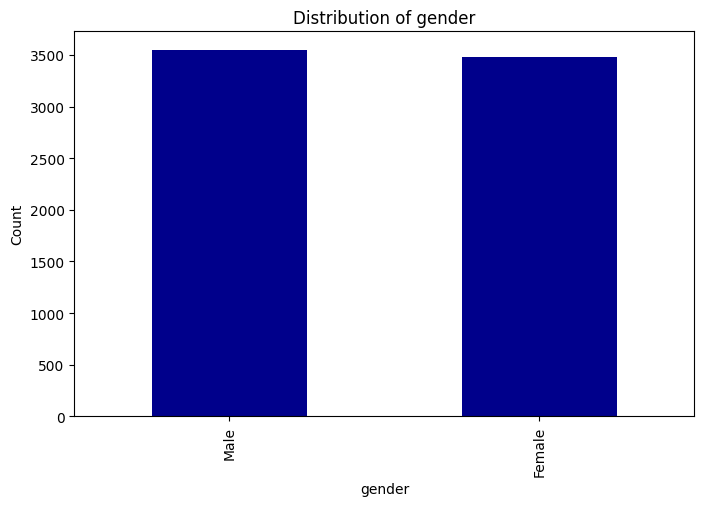

La columna SeniorCitizen presenta : SeniorCitizen
Yes    1142
No     5890
Name: count, dtype: int64


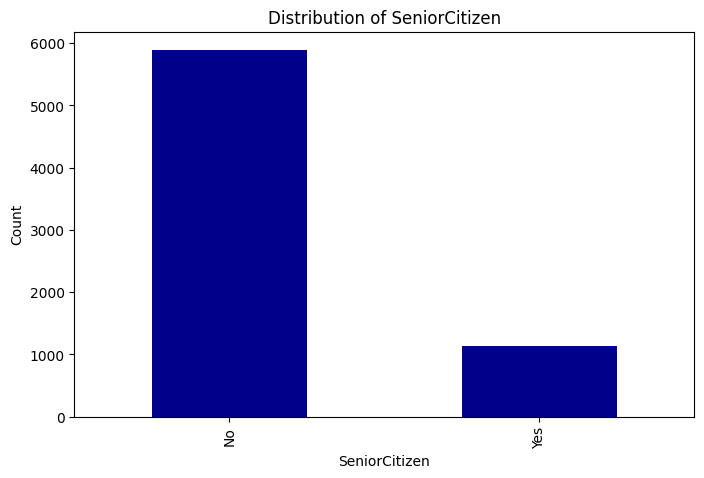

La columna Partner presenta : Partner
Yes    3393
No     3639
Name: count, dtype: int64


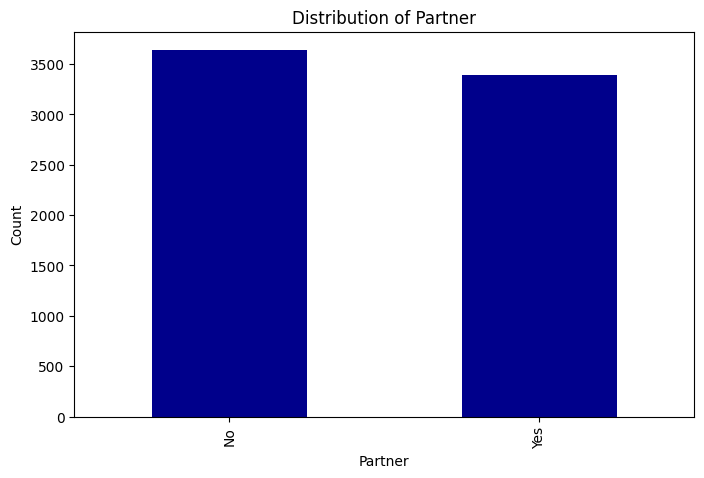

La columna Dependents presenta : Dependents
Yes    2099
No     4933
Name: count, dtype: int64


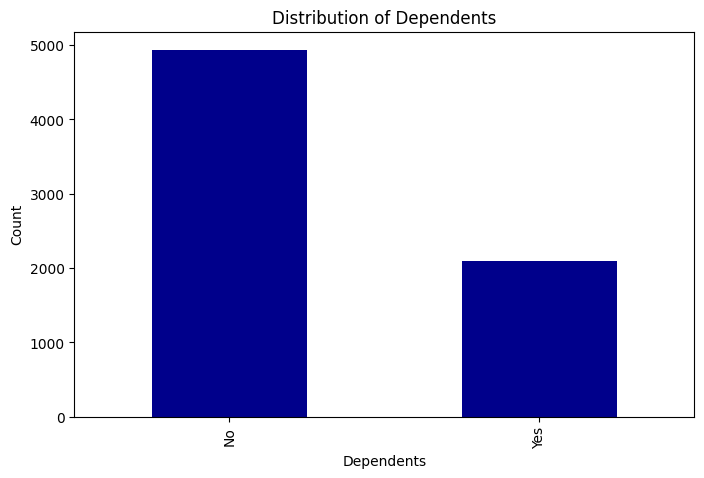

La columna PhoneService presenta : PhoneService
No      680
Yes    6352
Name: count, dtype: int64


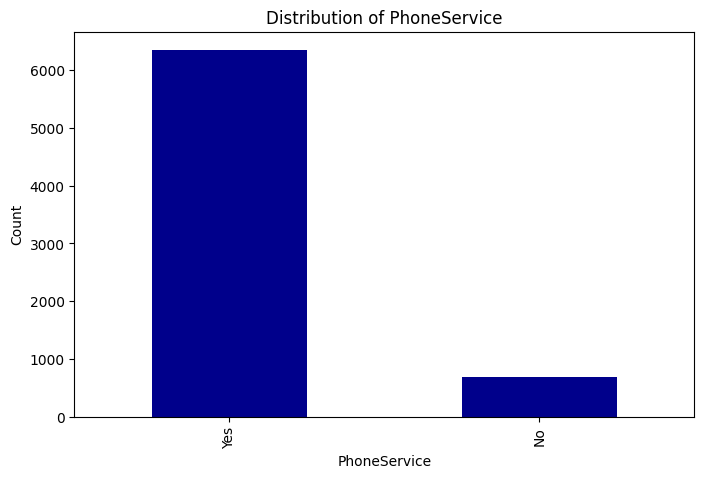

La columna MultipleLines presenta : MultipleLines
No phone service     680
Yes                 2967
No                  3385
Name: count, dtype: int64


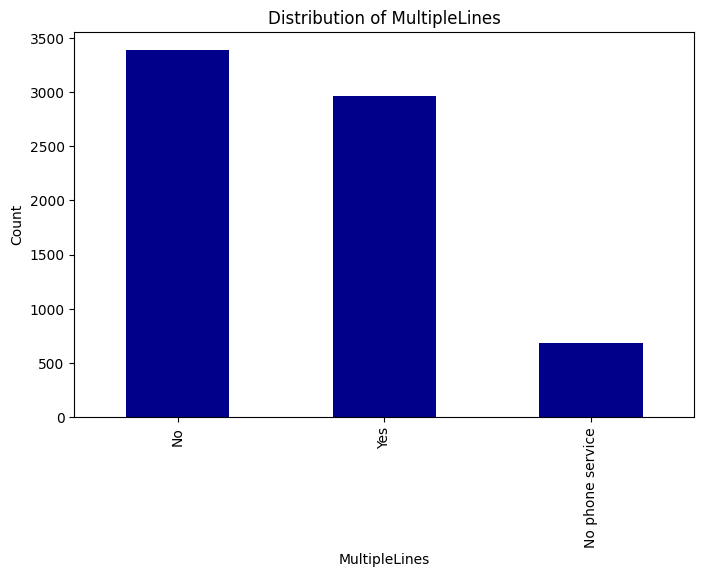

La columna InternetService presenta : InternetService
No             1520
DSL            2416
Fiber optic    3096
Name: count, dtype: int64


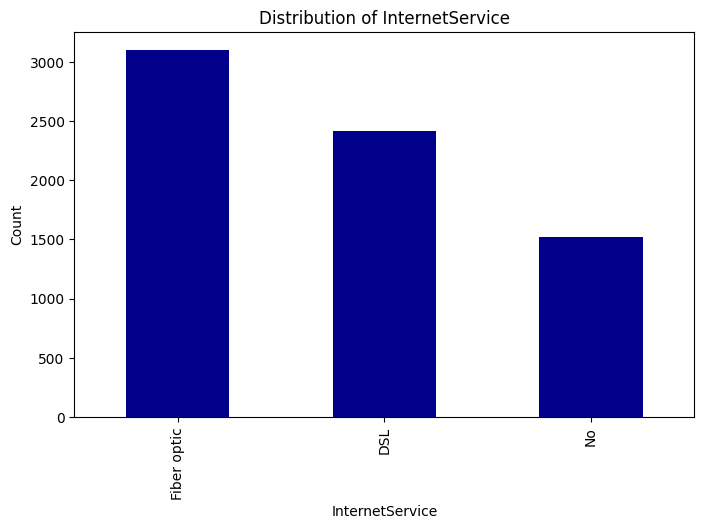

La columna OnlineSecurity presenta : OnlineSecurity
Yes    2015
No     5017
Name: count, dtype: int64


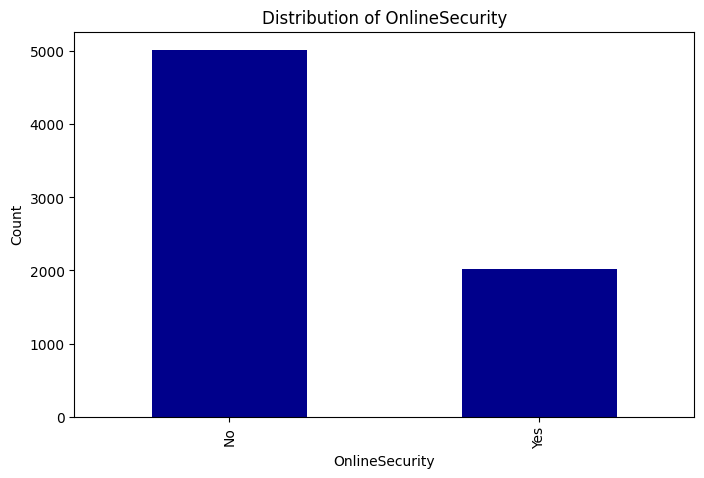

La columna OnlineBackup presenta : OnlineBackup
Yes    2425
No     4607
Name: count, dtype: int64


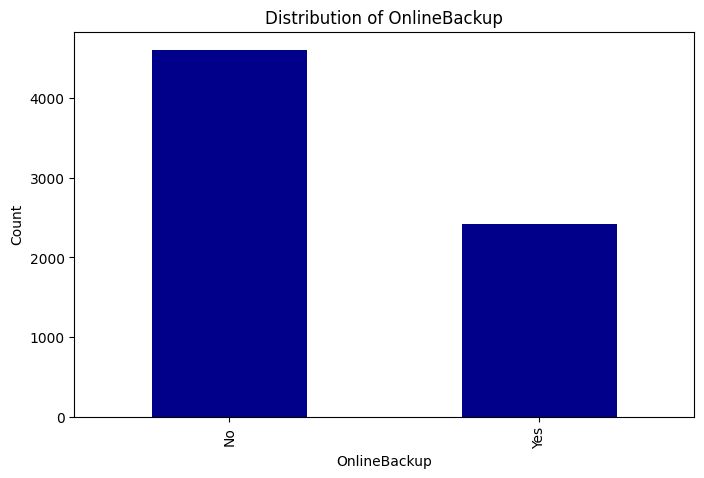

La columna DeviceProtection presenta : DeviceProtection
Yes    2418
No     4614
Name: count, dtype: int64


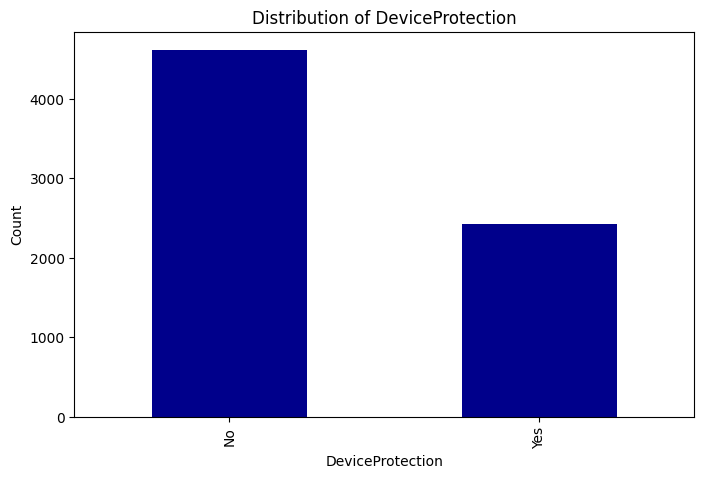

La columna TechSupport presenta : TechSupport
Yes    2040
No     4992
Name: count, dtype: int64


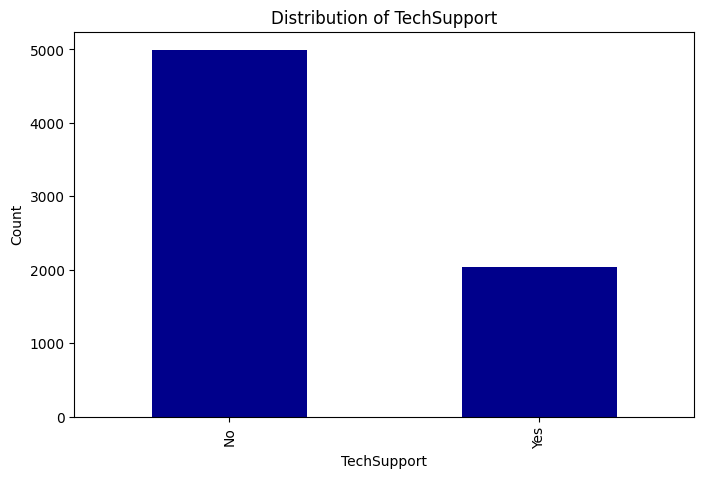

La columna StreamingTV presenta : StreamingTV
Yes    2703
No     4329
Name: count, dtype: int64


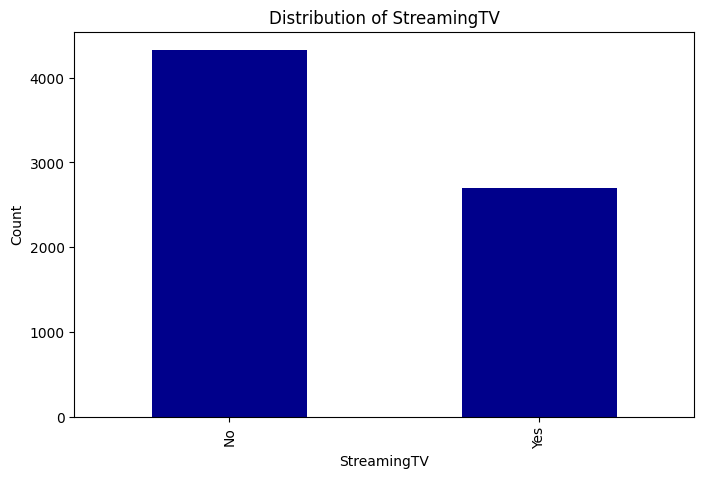

La columna StreamingMovies presenta : StreamingMovies
Yes    2731
No     4301
Name: count, dtype: int64


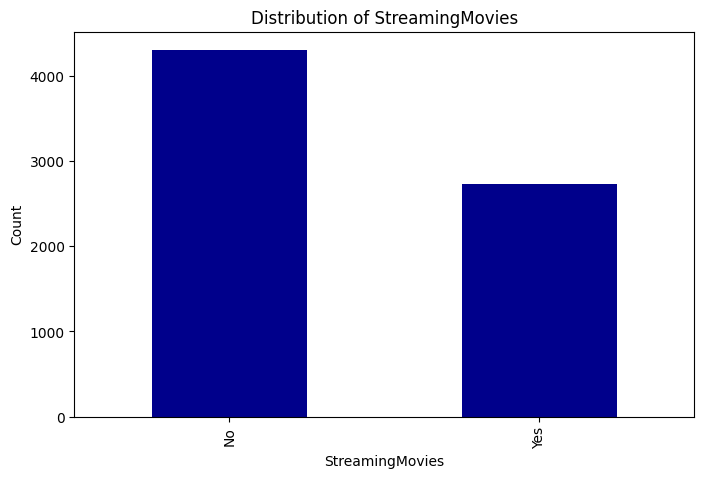

La columna Contract presenta : Contract
One year          1472
Two year          1685
Month-to-month    3875
Name: count, dtype: int64


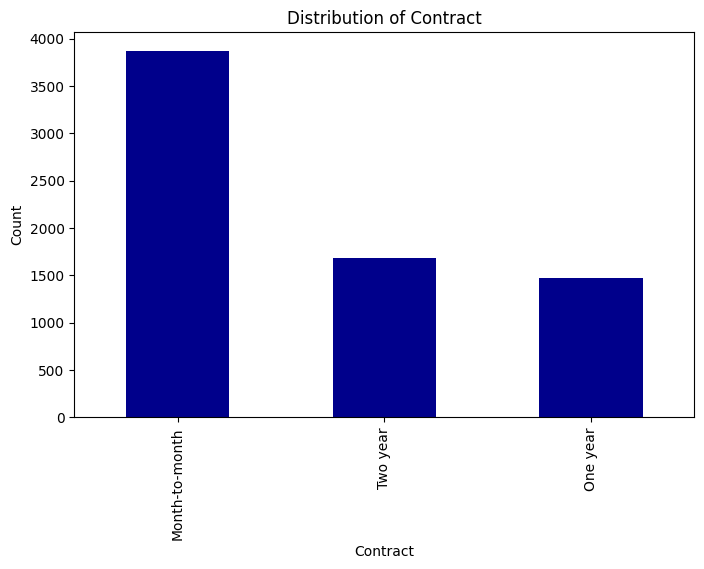

La columna PaperlessBilling presenta : PaperlessBilling
No     2864
Yes    4168
Name: count, dtype: int64


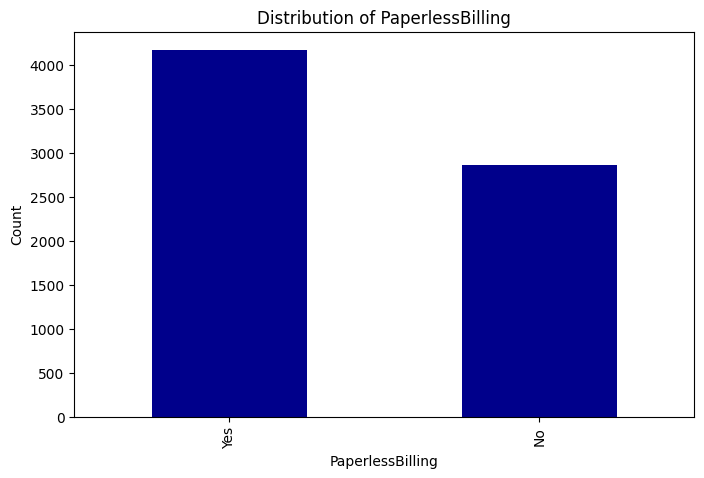

La columna PaymentMethod presenta : PaymentMethod
Credit card (automatic)      1521
Bank transfer (automatic)    1542
Mailed check                 1604
Electronic check             2365
Name: count, dtype: int64


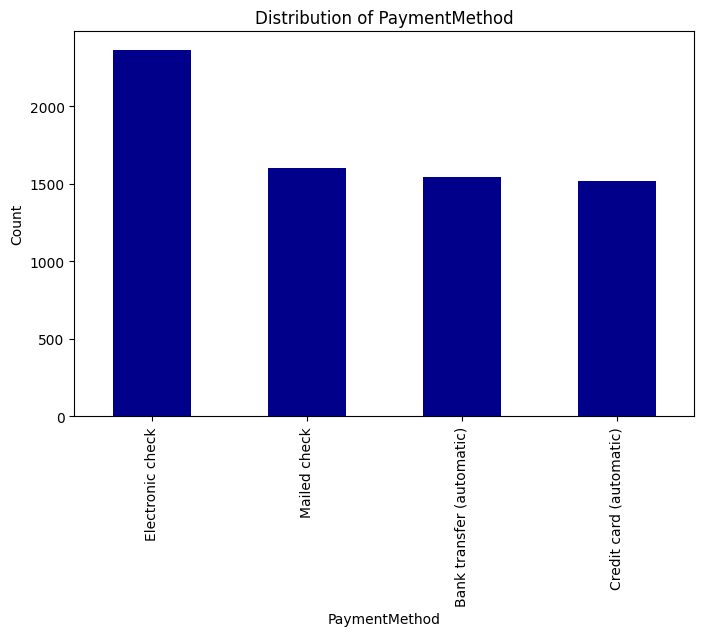

La columna Churn presenta : Churn
Yes    1869
No     5163
Name: count, dtype: int64


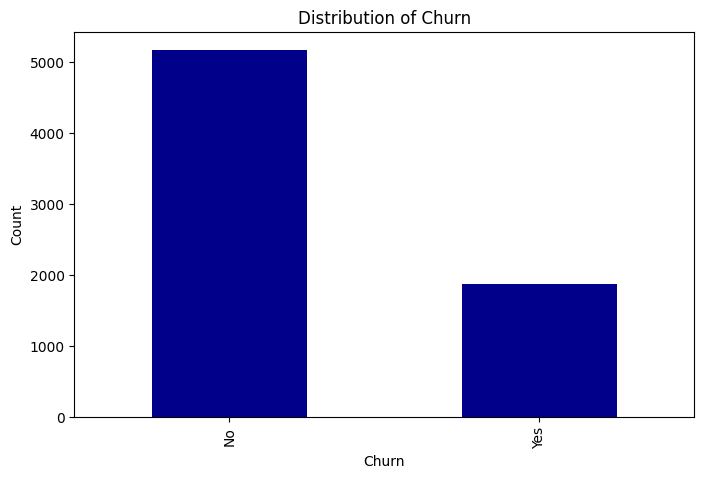

In [21]:
columnas_category = ['gender', 'SeniorCitizen', 'Partner', 'Dependents','PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod','Churn']

def analisis_columnas(df, columna):

    print(f"La columna {columna} presenta : {df[columna].value_counts().sort_values()}")

    df[columna].value_counts().plot(kind="bar", color="darkblue", figsize=(8,5))
    plt.title(f"Distribution of {columna}")
    plt.xlabel(f"{columna}")
    plt.ylabel("Count")
    plt.show()

for columna in columnas_category:
    analisis_columnas(customer_df, columna)

In [22]:
churn_yes = customer_df[customer_df["Churn"].eq("Yes")]
churn_no = customer_df[customer_df["Churn"].eq("No")]

def analisis(column):

    tablas = [("Churm Yes",churn_yes),("Churm No",churn_no)]

    for titulo, tabla in tablas:

        tb = tabla[column].value_counts(normalize=True).mul(100).round(2)

        print(tb)

        ax = tb.plot(kind="bar")
        ax.bar_label( ax.containers[0],fmt="%.1f%%")
        plt.xticks(rotation=0)
        plt.title(f" {column} - {titulo}")
        plt.ylabel("Porcentaje")
        plt.show()

SeniorCitizen
No     74.53
Yes    25.47
Name: proportion, dtype: float64


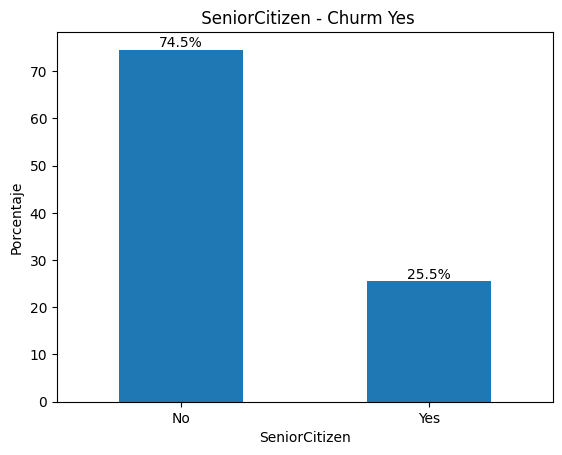

SeniorCitizen
No     87.1
Yes    12.9
Name: proportion, dtype: float64


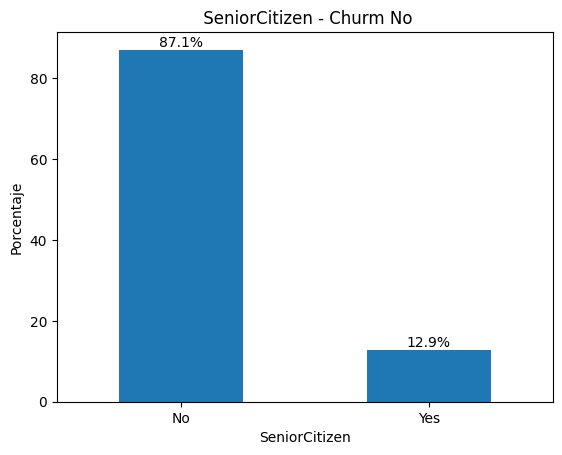

In [23]:
analisis("SeniorCitizen")

Se observa que los adultos mayores presentan una mayor proporción de churn (25,47%) en comparación con los clientes que permanecen en la empresa (12,90%). Esto sugiere que pertenecer al grupo de adultos mayores podría estar asociado con una mayor probabilidad de abandono.

Partner
No     64.21
Yes    35.79
Name: proportion, dtype: float64


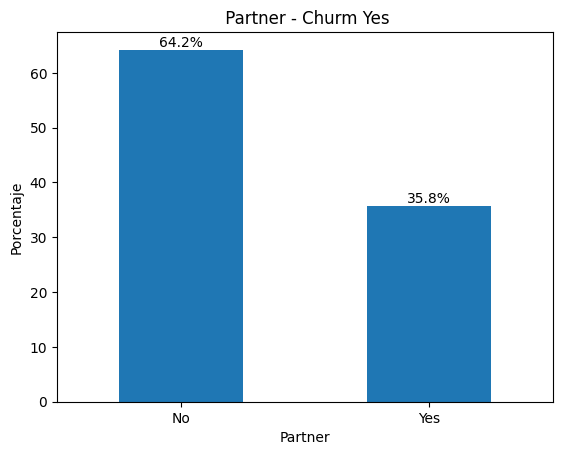

Partner
Yes    52.76
No     47.24
Name: proportion, dtype: float64


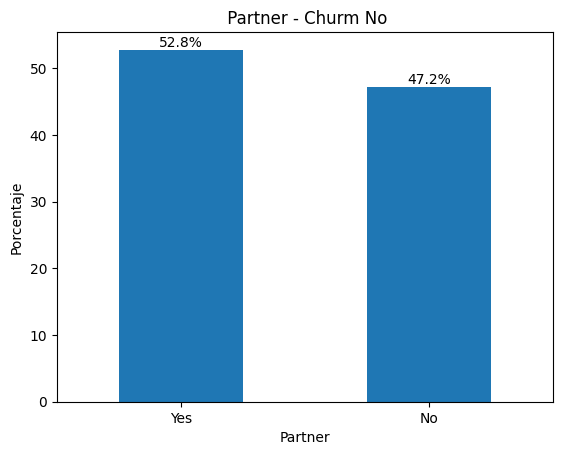

In [24]:
analisis("Partner")

Los clientes que abandonaron el servicio presentan una mayor proporción de personas sin pareja (64,21%), mientras que entre quienes permanecen en la empresa predominan ligeramente los clientes con pareja (52,76%). Esto podría indicar que los clientes con pareja tienden a permanecer más tiempo en el servicio.

Dependents
No     82.56
Yes    17.44
Name: proportion, dtype: float64


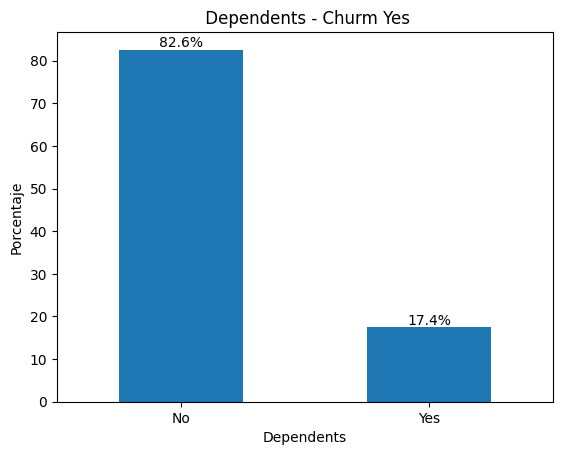

Dependents
No     65.66
Yes    34.34
Name: proportion, dtype: float64


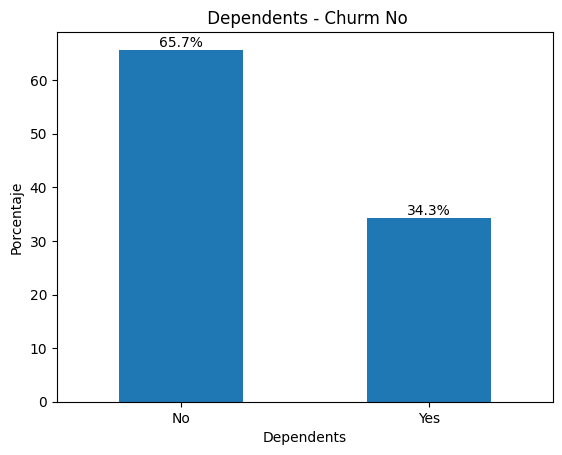

In [25]:
analisis("Dependents")

Los clientes con churn muestran una menor proporción de personas con dependientes (17,44%) respecto a quienes permanecen en la empresa (34,34%). Esto sugiere que tener dependientes podría estar asociado con una mayor permanencia en el servicio.

PhoneService
Yes    90.9
No      9.1
Name: proportion, dtype: float64


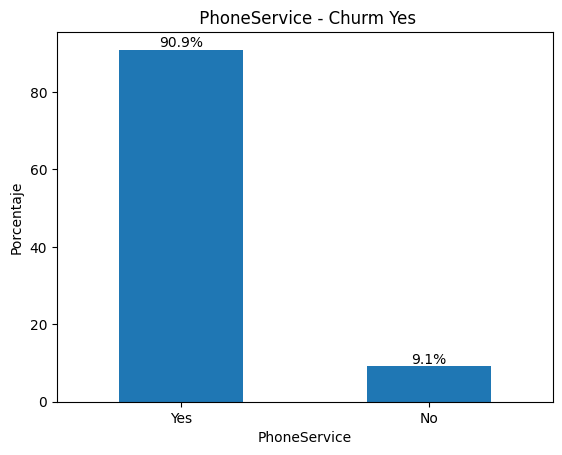

PhoneService
Yes    90.12
No      9.88
Name: proportion, dtype: float64


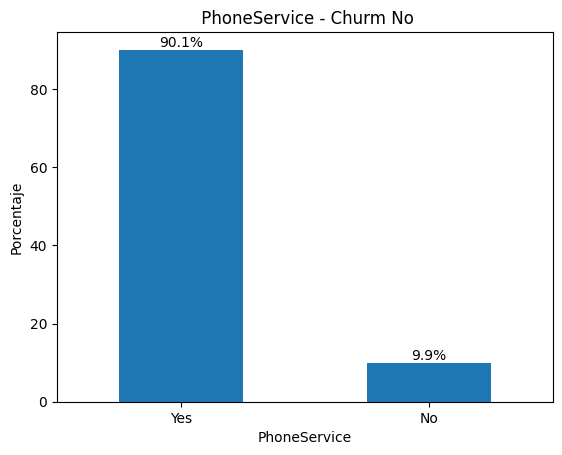

In [26]:
analisis("PhoneService")

La distribución es prácticamente idéntica entre ambos grupos, con aproximadamente un 90% de clientes que poseen servicio telefónico. Esto indica que esta variable no parece presentar una relación significativa con el churn.

MultipleLines
Yes                 45.48
No                  45.43
No phone service     9.10
Name: proportion, dtype: float64


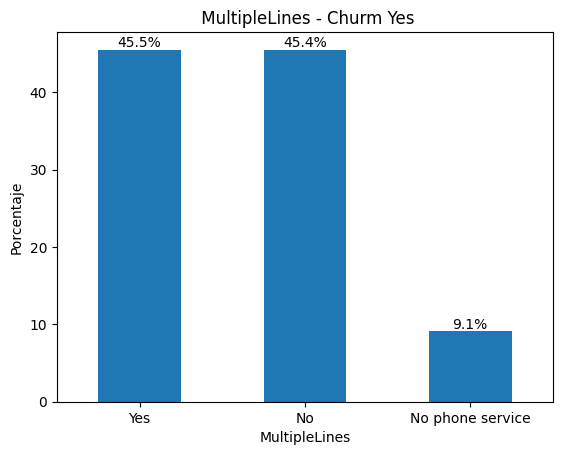

MultipleLines
No                  49.12
Yes                 41.00
No phone service     9.88
Name: proportion, dtype: float64


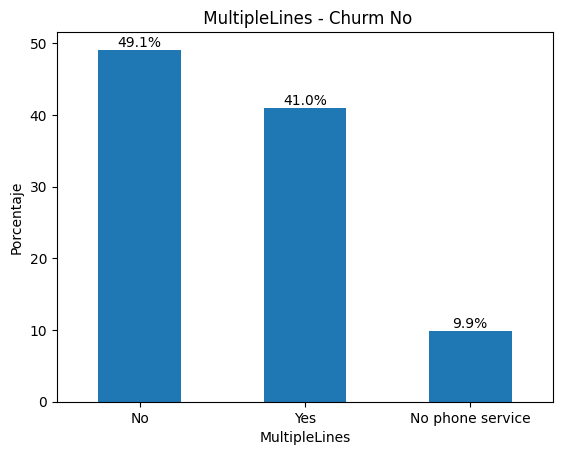

In [27]:
analisis("MultipleLines")

La distribución de clientes con y sin múltiples líneas es muy similar entre ambos grupos. Los clientes que abandonaron el servicio presentan prácticamente la misma proporción de usuarios con múltiples líneas (45,48%) y sin múltiples líneas (45,43%), mientras que entre quienes permanecen existe una ligera predominancia de clientes con una única línea (49,12%). En general, esta variable no muestra una diferencia suficientemente marcada como para considerarla un factor determinante en el churn.

InternetService
Fiber optic    69.40
DSL            24.56
No              6.05
Name: proportion, dtype: float64


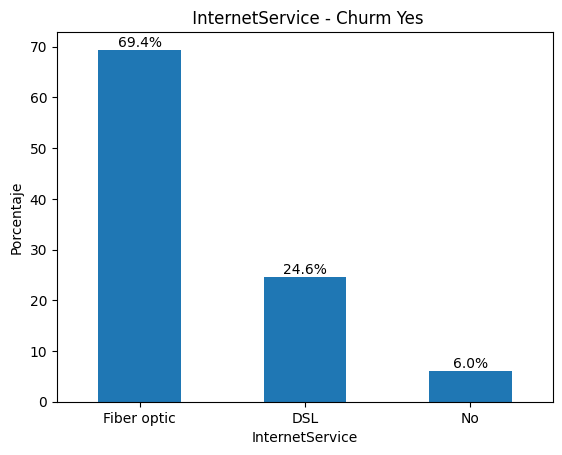

InternetService
DSL            37.90
Fiber optic    34.84
No             27.25
Name: proportion, dtype: float64


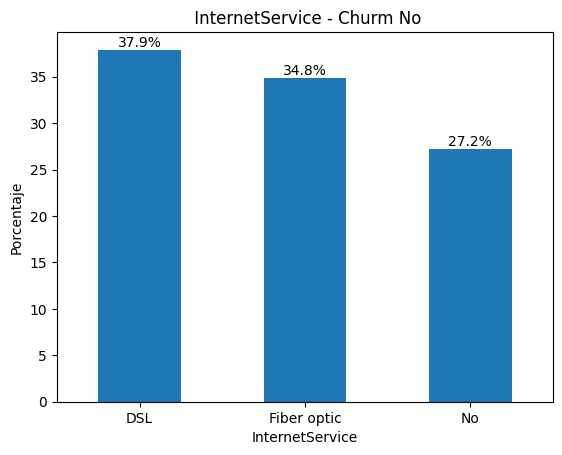

In [28]:
analisis("InternetService")

Se observa una diferencia marcada en el tipo de servicio contratado. Entre los clientes que abandonaron la empresa predomina Fiber optic (69,40%), mientras que entre quienes permanecen existe una distribución más equilibrada e incluso una mayor presencia de clientes sin servicio de Internet. Esto sugiere una posible asociación entre el servicio de fibra óptica y una mayor tasa de churn.

OnlineSecurity
No     84.22
Yes    15.78
Name: proportion, dtype: float64


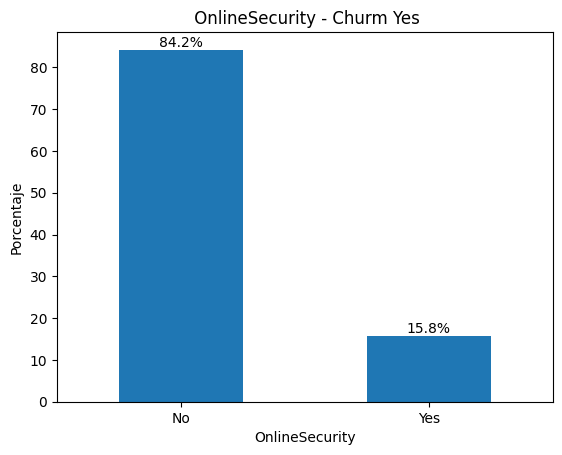

OnlineSecurity
No     66.69
Yes    33.31
Name: proportion, dtype: float64


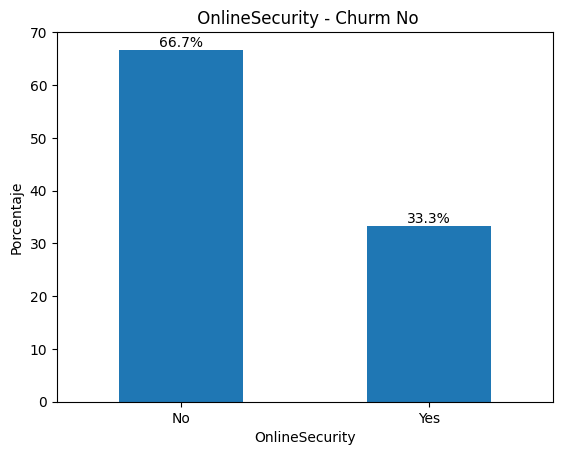

In [29]:
analisis("OnlineSecurity")

La ausencia del servicio de seguridad en línea es considerablemente más frecuente entre los clientes que abandonaron la empresa (84,22%) que entre quienes permanecen (66,69%). Esto indica que disponer de este servicio podría estar relacionado con una mayor retención de clientes.

DeviceProtection
No     70.84
Yes    29.16
Name: proportion, dtype: float64


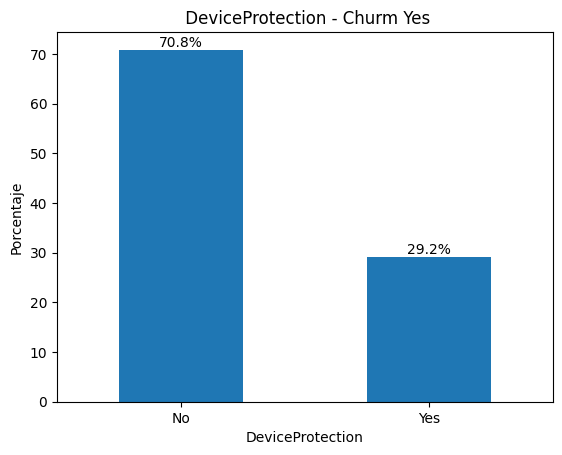

DeviceProtection
No     63.72
Yes    36.28
Name: proportion, dtype: float64


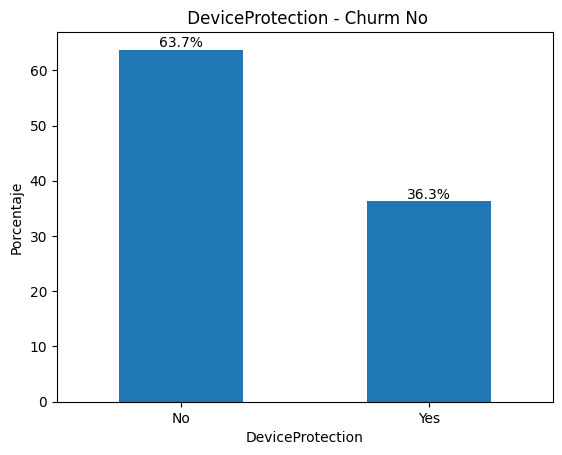

In [30]:
analisis("DeviceProtection")

Los clientes que permanecen en la empresa presentan una mayor contratación del servicio de protección de dispositivos. Aunque la diferencia no es tan pronunciada como en otras variables, podría indicar que este servicio contribuye a la permanencia del cliente.

TechSupport
No     83.41
Yes    16.59
Name: proportion, dtype: float64


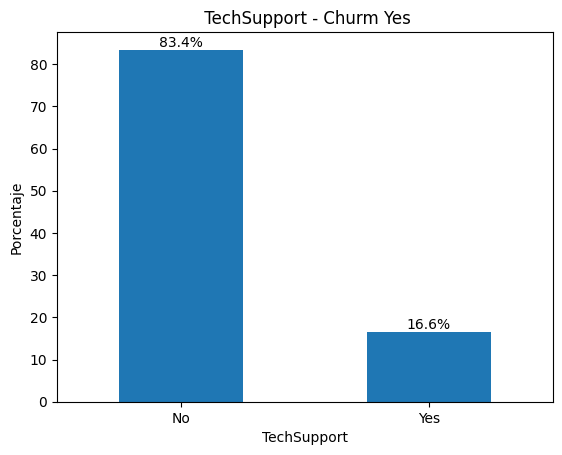

TechSupport
No     66.49
Yes    33.51
Name: proportion, dtype: float64


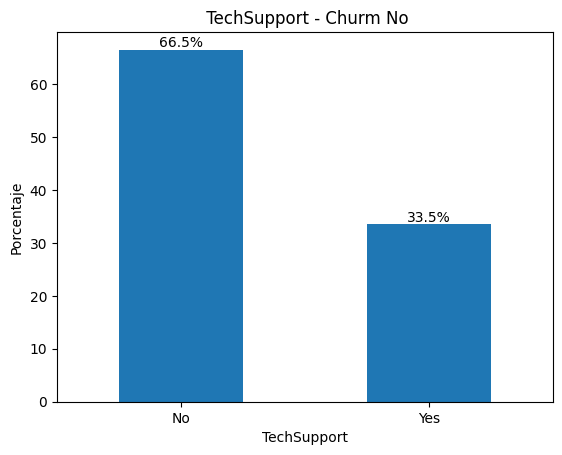

In [31]:
analisis("TechSupport")

La diferencia entre ambos grupos es evidente. Solo el 16,59% de los clientes que abandonaron contaban con soporte técnico, frente al 33,51% de los clientes que permanecen. Esto sugiere que disponer de soporte técnico está asociado con una menor probabilidad de churn.

StreamingTV
No     56.45
Yes    43.55
Name: proportion, dtype: float64


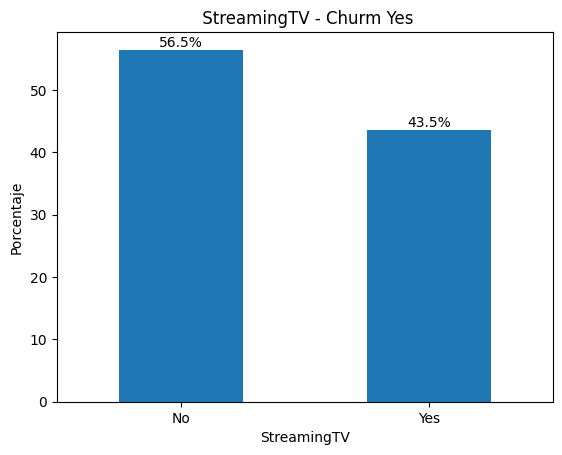

StreamingTV
No     63.41
Yes    36.59
Name: proportion, dtype: float64


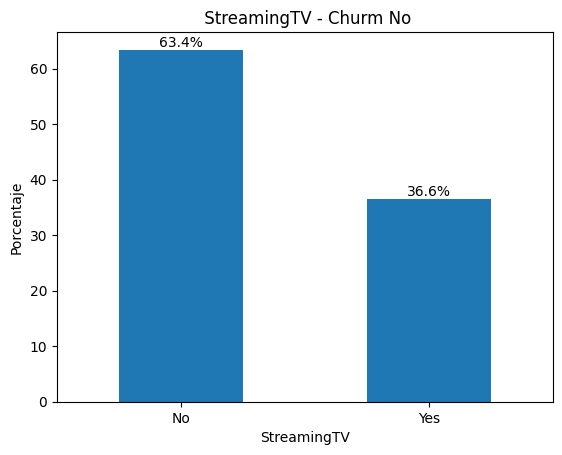

In [32]:
analisis("StreamingTV")

Las diferencias observadas entre ambos grupos son moderadas. Si bien los clientes que abandonan presentan una proporción ligeramente mayor de usuarios del servicio, la diferencia no parece suficientemente marcada como para considerarla un factor determinante.

StreamingMovies
No     56.23
Yes    43.77
Name: proportion, dtype: float64


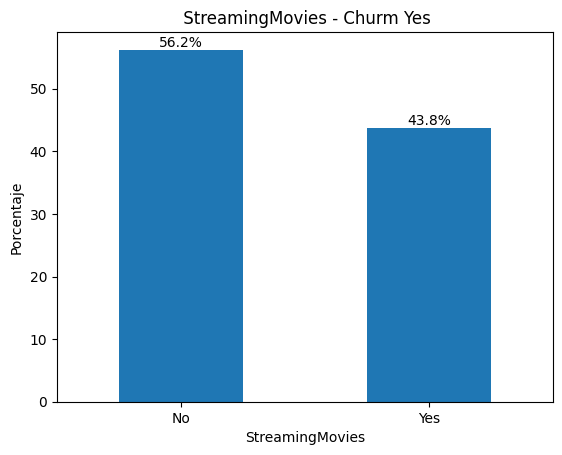

StreamingMovies
No     62.95
Yes    37.05
Name: proportion, dtype: float64


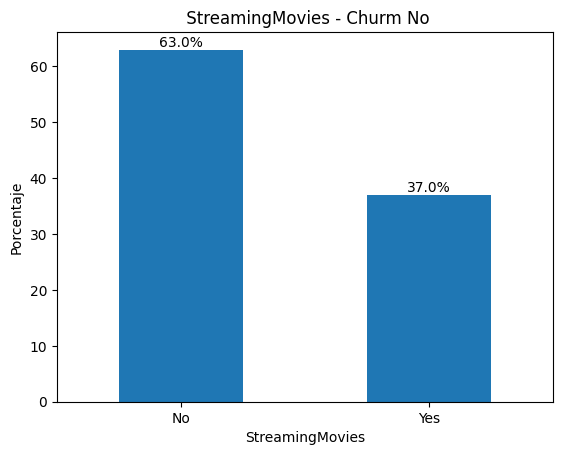

In [33]:
analisis("StreamingMovies")

Se observa un comportamiento similar al de StreamingTV. La distribución entre ambos grupos es relativamente parecida, por lo que esta variable no parece mostrar una asociación fuerte con el abandono.

Contract
Month-to-month    88.55
One year           8.88
Two year           2.57
Name: proportion, dtype: float64


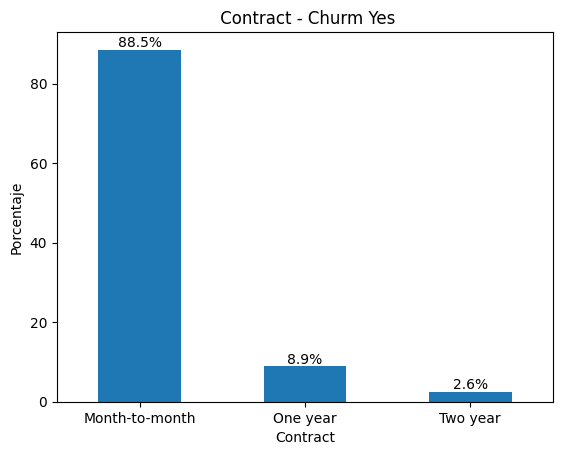

Contract
Month-to-month    43.00
Two year          31.71
One year          25.30
Name: proportion, dtype: float64


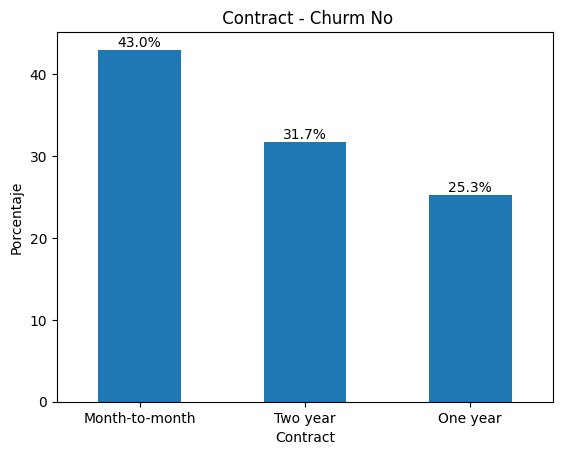

In [34]:
analisis("Contract")

Esta es la variable que presenta la diferencia más significativa de todo el análisis. El 88,55% de los clientes que abandonaron la empresa poseen un contrato Month-to-month, mientras que los contratos de uno y dos años predominan entre los clientes que permanecen. Esto indica que el tipo de contrato es uno de los factores más relacionados con el churn.

PaperlessBilling
Yes    74.91
No     25.09
Name: proportion, dtype: float64


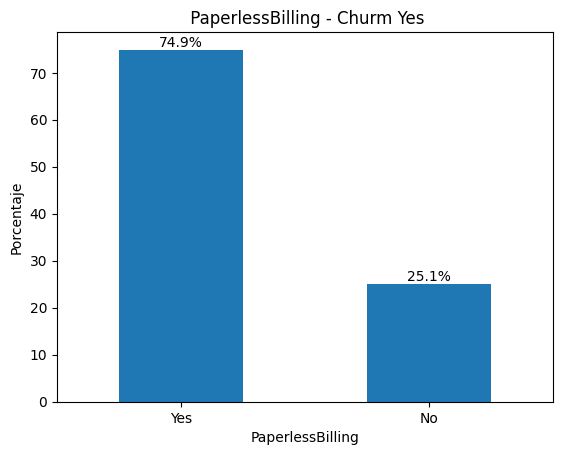

PaperlessBilling
Yes    53.61
No     46.39
Name: proportion, dtype: float64


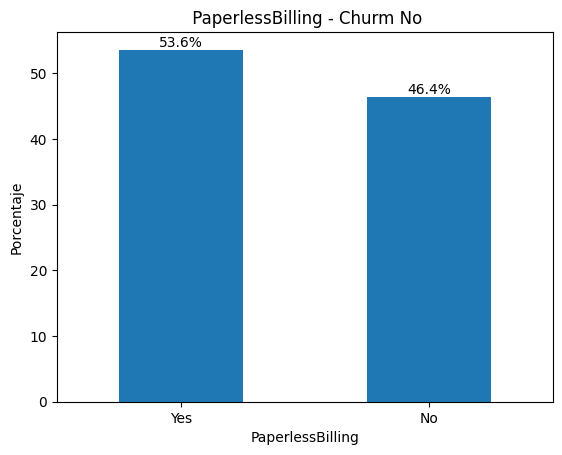

In [35]:
analisis("PaperlessBilling")

Los clientes que abandonan utilizan con mayor frecuencia la facturación electrónica (74,91%) en comparación con quienes permanecen (53,61%). Aunque existe una diferencia apreciable, esta variable podría estar reflejando el perfil del cliente más que una causa directa del abandono.

PaymentMethod
Electronic check             57.30
Mailed check                 16.48
Bank transfer (automatic)    13.80
Credit card (automatic)      12.41
Name: proportion, dtype: float64


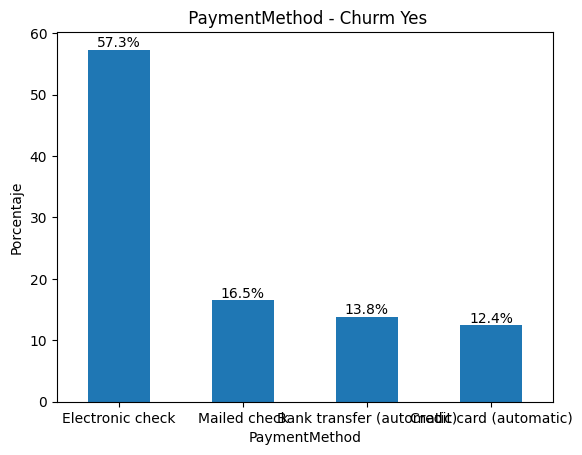

PaymentMethod
Mailed check                 25.10
Electronic check             25.06
Credit card (automatic)      24.97
Bank transfer (automatic)    24.87
Name: proportion, dtype: float64


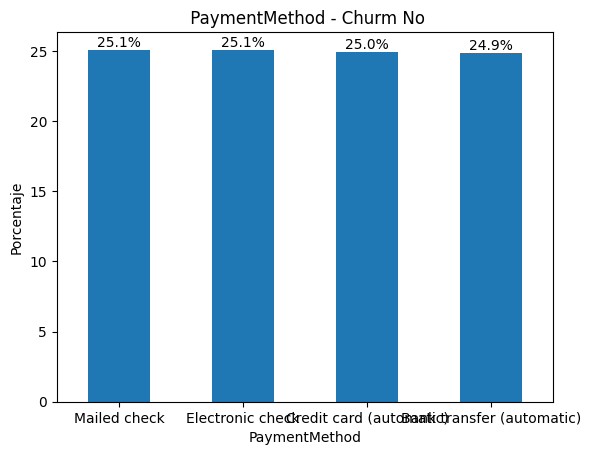

In [36]:
analisis("PaymentMethod")

Más de la mitad de los clientes que abandonaron utilizan Electronic check como método de pago (57,30%), mientras que entre los clientes que permanecen los métodos de pago se distribuyen de forma mucho más equilibrada. Esto sugiere que el uso de cheque electrónico está asociado con una mayor probabilidad de churn.

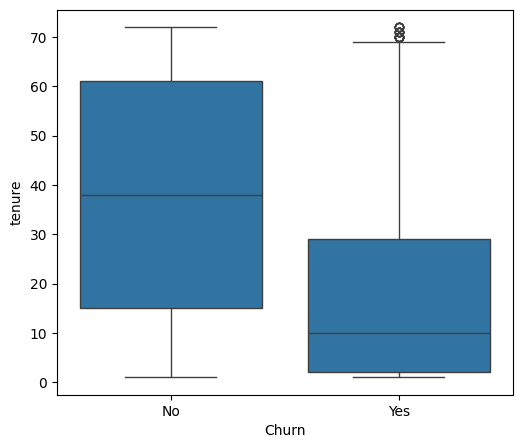

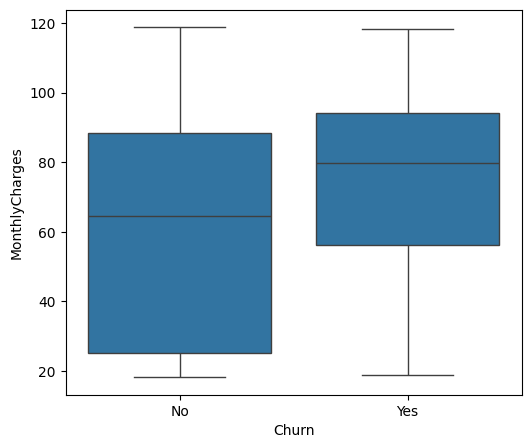

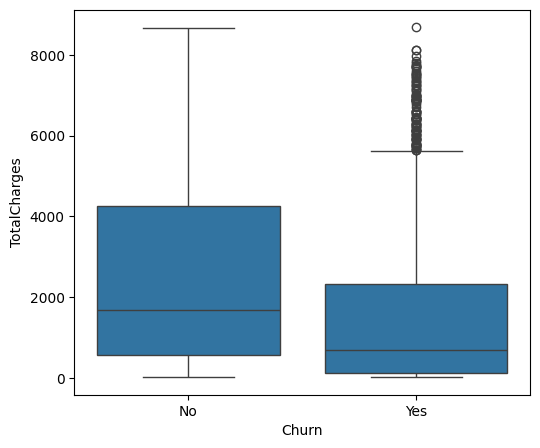

In [37]:
columnas_num = ["tenure","MonthlyCharges","TotalCharges"]

def analisis_columnas(df, columna):

    fig = plt.figure(figsize=(20,5))
    fig.add_subplot(131)
    sns.boxplot(data=df, x="Churn", y=columna)
    plt.show()


for columna in columnas_num:
    analisis_columnas(customer_df, columna)

In [38]:
customer_df.groupby("Churn")[["tenure", "MonthlyCharges", "TotalCharges"]].agg(
    ["mean", "median", "std", "min", "max"]
).round(2)

tenure                       MonthlyCharges                       \
        mean median    std min max           mean median    std    min   
Churn                                                                    
No     37.65   38.0  24.08   1  72          61.31  64.45  31.09  18.25   
Yes    17.98   10.0  19.53   1  72          74.44  79.65  24.67  18.85   

              TotalCharges                                    
          max         mean   median      std    min      max  
Churn                                                         
No     118.75      2555.34  1683.60  2329.46  18.80  8672.45  
Yes    118.35      1531.80   703.55  1890.82  18.85  8684.80

El análisis de las variables numéricas muestra diferencias claras entre ambos grupos de clientes. En promedio, los clientes que abandonaron la empresa presentan una menor antigüedad (tenure), mayores cargos mensuales (MonthlyCharges) y un menor gasto total acumulado (TotalCharges) respecto a quienes permanecen en el servicio. Estas diferencias respaldan los resultados obtenidos durante el análisis de las variables categóricas y sugieren que la permanencia del cliente y el costo mensual del servicio son factores estrechamente relacionados con el churn. Si bien los diagramas de caja muestran la presencia de algunos valores atípicos, estos no resultan lo suficientemente significativos como para justificar su eliminación, ya que representan casos válidos dentro del comportamiento de los clientes.

#### Conclusion

El análisis exploratorio permitió identificar diferencias significativas entre los clientes que abandonaron el servicio y aquellos que permanecieron en la empresa.

Entre las variables categóricas, el tipo de contrato (Contract) mostró la asociación más fuerte con el churn, observándose que la gran mayoría de los clientes que abandonaron la empresa tenían contratos Month-to-month. También se identificó una mayor proporción de abandono entre los clientes con Fiber optic, aquellos que utilizaban Electronic check como método de pago y los clientes sin servicios adicionales como OnlineSecurity y TechSupport.

Respecto a las variables numéricas, se observó que los clientes con churn presentan una menor antigüedad (tenure), mayores cargos mensuales (MonthlyCharges) y un menor gasto total acumulado (TotalCharges) en comparación con los clientes que permanecieron en la empresa. Estos resultados sugieren que el abandono suele concentrarse en clientes relativamente nuevos y con costos mensuales más elevados.

En conjunto, los hallazgos obtenidos durante el análisis exploratorio respaldan la hipótesis planteada al inicio del proyecto y permiten identificar las variables con mayor potencial predictivo para el desarrollo del modelo de Machine Learning.

A partir de estos resultados, la siguiente etapa consistirá en preparar el conjunto de datos para el entrenamiento de modelos de Machine Learning, evaluando la capacidad de estas variables para predecir el abandono de clientes.

Data Preparation for Machine Learning

In [39]:
customer_ml = customer_df.copy()

In [40]:
customer_ml = customer_ml.drop(columns=["customerID"])

In [41]:
for columna in customer_ml.select_dtypes(include="category"):
    customer_ml[columna] = customer_ml[columna].astype("string")

In [42]:
columnas = columnas = [
    "Partner","Dependents","PhoneService","OnlineSecurity",
    "OnlineBackup","DeviceProtection","TechSupport","StreamingTV",
    "StreamingMovies","PaperlessBilling","SeniorCitizen","Churn"
]

for columna in columnas:
    customer_ml[columna] = customer_ml[columna].replace({"Yes": 1,"No": 0})
    customer_ml[columna] = customer_ml[columna].astype(int)

In [43]:
customer_ml = pd.get_dummies(customer_ml, columns=["gender","InternetService","Contract","PaymentMethod","MultipleLines"])

In [44]:
columnas_bool = customer_ml.select_dtypes(include="bool").columns

customer_ml[columnas_bool] = customer_ml[columnas_bool].astype(int)

In [45]:
customer_ml.head()

,SeniorCitizen,Partner,Dependents,tenure,PhoneService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,...,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes
0,0,1,0,1,0,0,1,0,0,0,...,1,0,0,0,0,1,0,0,1,0
1,0,0,0,34,1,1,0,1,0,0,...,0,1,0,0,0,0,1,1,0,0
2,0,0,0,2,1,1,1,0,0,0,...,1,0,0,0,0,0,1,1,0,0
3,0,0,0,45,0,1,0,1,1,0,...,0,1,0,1,0,0,0,0,1,0
4,0,0,0,2,1,0,0,0,0,0,...,1,0,0,0,0,1,0,1,0,0


In [46]:
y = customer_ml["Churn"]

In [47]:
x = customer_ml.drop(columns="Churn")

In [48]:
# Train Test Split
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [49]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(5625, 29)
(1407, 29)
(5625,)
(1407,)


### Modelado

In [50]:
modelo_lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)

modelo_lr.fit(x_train, y_train)

c:\Users\Usuario\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [51]:
y_pred_lr = modelo_lr.predict(x_test)

In [52]:
y_prob_lr = modelo_lr.predict_proba(x_test)

In [53]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print(f"Accuracy: {accuracy_lr:.4f}")

Accuracy: 0.8017


In [54]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.64      0.57      0.60       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [55]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

print(cm_lr)

[[915 118]
 [161 213]]


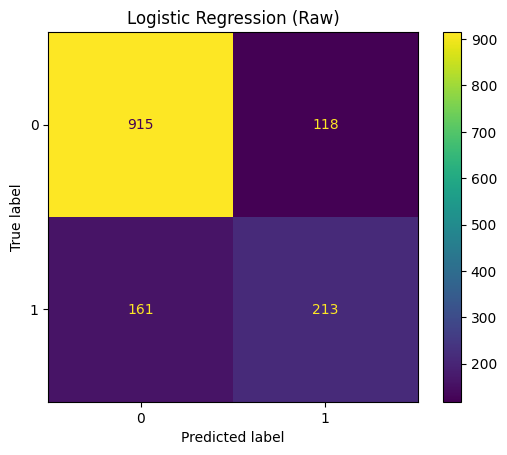

In [56]:
ConfusionMatrixDisplay.from_predictions( y_test, y_pred_lr)
plt.title("Logistic Regression (Raw)")
plt.show()

In [57]:
auc_lr = roc_auc_score(y_test, y_prob_lr[:, 1])

print(f"ROC-AUC: {auc_lr:.4f}")

ROC-AUC: 0.8366


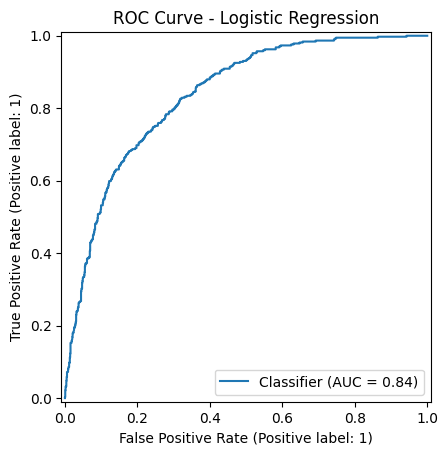

In [58]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_lr[:,1]
)

plt.title("ROC Curve - Logistic Regression")
plt.show()

#### Escalamos

In [59]:
scaler = StandardScaler()

In [60]:
x_train_scaled = scaler.fit_transform(x_train)

In [61]:
x_test_scaled = scaler.transform(x_test)

In [62]:
modelo_lr_scaled = LogisticRegression(
    random_state=42,
    max_iter=1000
)

modelo_lr_scaled.fit(x_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [63]:
y_pred_lr_scaled = modelo_lr_scaled.predict(x_test_scaled)
y_prob_lr_scaled = modelo_lr_scaled.predict_proba(x_test_scaled)

In [64]:
accuracy_lr_scaled = accuracy_score(y_test,y_pred_lr_scaled)
print(f"Accuracy: {accuracy_lr_scaled:.4f}")


Accuracy: 0.8038


In [65]:
print(classification_report(
    y_test,
    y_pred_lr_scaled
))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [66]:
cm_lr_scaled = confusion_matrix(
    y_test,
    y_pred_lr_scaled
)

print(cm_lr_scaled)

[[916 117]
 [159 215]]


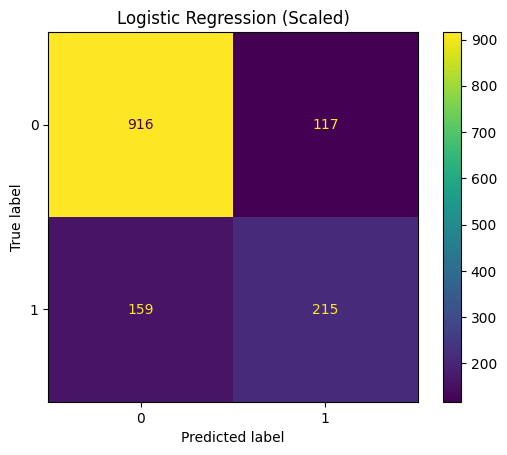

In [67]:
# Con escala
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr_scaled)

plt.title("Logistic Regression (Scaled)")
plt.show()

In [68]:
auc_lr_scaled = roc_auc_score(y_test, y_prob_lr_scaled[:,1])

print(f"ROC-AUC: {auc_lr_scaled:.4f}")

ROC-AUC: 0.8357


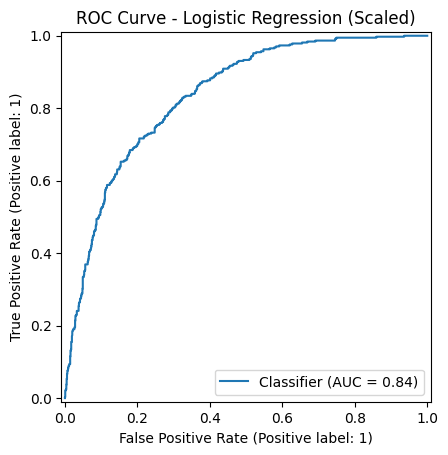

In [69]:
RocCurveDisplay.from_predictions( y_test, y_prob_lr_scaled[:,1])

plt.title("ROC Curve - Logistic Regression (Scaled)")
plt.show()

#### Conclusion
Se entrenaron dos versiones de la Regresión Logística: una utilizando las variables originales y otra con las variables estandarizadas mediante StandardScaler. Aunque ambas obtuvieron un rendimiento muy similar, la versión escalada presentó una ligera mejora en Accuracy, Precision y F1-score, además de una matriz de confusión con menos errores de clasificación. El valor de ROC-AUC fue prácticamente idéntico en ambos casos (≈0.84), lo que indica que el poder discriminativo del modelo no cambió significativamente. Debido a la estabilidad del entrenamiento y a la ligera mejora en las métricas, la versión escalada se utilizará como modelo base para las comparaciones posteriores.

##### Decision Tree

In [70]:
modelo_dt = DecisionTreeClassifier(
    random_state=42
)

modelo_dt.fit(x_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [71]:
y_pred_dt = modelo_dt.predict(x_test)

In [72]:
y_prob_dt = modelo_dt.predict_proba(x_test)

In [73]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)

print(f"Accuracy: {accuracy_dt:.4f}")

Accuracy: 0.7150


In [74]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.81      0.80      0.81      1033
           1       0.46      0.48      0.47       374

    accuracy                           0.71      1407
   macro avg       0.64      0.64      0.64      1407
weighted avg       0.72      0.71      0.72      1407



In [75]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

print(cm_dt)

[[828 205]
 [196 178]]


In [76]:
auc_dt = roc_auc_score(y_test, y_prob_dt[:, 1])

print(f"ROC-AUC: {auc_dt:.4f}")

ROC-AUC: 0.6382


#### Conclusion

Se entrenó un Árbol de Decisión sin restricciones para utilizarlo como modelo base y compararlo con la Regresión Logística. Aunque este tipo de modelo permite capturar relaciones no lineales entre las variables, su rendimiento fue considerablemente inferior en todas las métricas evaluadas. La Accuracy descendió hasta 71.5% y el ROC-AUC se redujo a 0.64, evidenciando una menor capacidad para diferenciar entre clientes que abandonan el servicio y aquellos que permanecen. Asimismo, el modelo presentó un mayor número de falsos positivos y falsos negativos, por lo que la Regresión Logística continúa siendo la mejor alternativa entre los modelos evaluados hasta el momento.

#### Random Forest

In [77]:
modelo_rf = RandomForestClassifier(
    random_state=42,
    n_estimators=100
)

modelo_rf.fit(x_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [78]:
y_pred_rf = modelo_rf.predict(x_test)

y_prob_rf = modelo_rf.predict_proba(x_test)

In [79]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print(f"Accuracy: {accuracy_rf:.4f}")

Accuracy: 0.7875


In [80]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.63      0.50      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [81]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

[[921 112]
 [187 187]]


In [82]:
auc_rf = roc_auc_score(y_test, y_prob_rf[:,1])

print(f"ROC-AUC: {auc_rf:.4f}")

ROC-AUC: 0.8119


#### Conclusion

El modelo Random Forest mostró un rendimiento superior al Árbol de Decisión, evidenciando una mejor capacidad de generalización. Sin embargo, al compararlo con la Regresión Logística, obtuvo resultados ligeramente inferiores en las métricas más relevantes para este problema, especialmente en la detección de clientes que abandonan el servicio.

Si bien se trata de un modelo sólido y con un buen desempeño general, los resultados indican que no ofrece una mejora suficiente para justificar su elección como modelo final. Por este motivo, la Regresión Logística continúa siendo la alternativa más adecuada para este conjunto de datos, al proporcionar el mejor equilibrio entre rendimiento predictivo e interpretabilidad.

#### Conclusión de los modelos de Machine Learning

En este proyecto se evaluaron tres algoritmos de clasificación: Regresión Logística, Árbol de Decisión y Random Forest, utilizando las mismas métricas de evaluación (Accuracy, Precision, Recall, F1-score y ROC-AUC).

La Regresión Logística obtuvo el mejor rendimiento general, alcanzando un Accuracy de 80.38% y un ROC-AUC de 0.8357, además de presentar el mejor equilibrio entre precisión y capacidad para identificar clientes con riesgo de abandono. La estandarización de las variables produjo una ligera mejora en el rendimiento y permitió un entrenamiento más estable del modelo.

El Árbol de Decisión obtuvo el desempeño más bajo, con una disminución considerable en todas las métricas respecto a la Regresión Logística. Esto indica que un árbol individual no logró generalizar adecuadamente sobre los datos de prueba.

Por su parte, Random Forest mejoró claramente los resultados del Árbol de Decisión gracias a la combinación de múltiples árboles, reduciendo el sobreajuste. Sin embargo, no consiguió superar a la Regresión Logística, especialmente en métricas importantes como Recall y ROC-AUC.

En consecuencia, la Regresión Logística escalada fue seleccionada como el modelo final del proyecto, ya que presentó el mejor desempeño global y, además, ofrece una mayor interpretabilidad, permitiendo comprender con mayor facilidad qué factores influyen en la probabilidad de abandono de los clientes.


| Métrica           | Logistic Regression (Scaled) | Decision Tree | Random Forest |
| ----------------- | ---------------------------: | ------------: | ------------: |
| Accuracy          |                   **0.8038** |        0.7150 |        0.7875 |
| Precision (Churn) |                     **0.65** |          0.46 |          0.63 |
| Recall (Churn)    |                     **0.57** |          0.48 |          0.50 |
| F1-score (Churn)  |                     **0.61** |          0.47 |          0.56 |
| ROC-AUC           |                   **0.8357** |        0.6382 |        0.8119 |


#### Feature Importance

In [83]:
coeficientes = pd.DataFrame({
    "Variable": x_train.columns,
    "Coeficiente": modelo_lr.coef_[0]
})

In [84]:
top_positivas = (
    coeficientes
    .sort_values(by="Coeficiente", ascending=False)
    .head(5)
)

In [85]:
top_negativas = (
    coeficientes
    .sort_values(by="Coeficiente")
    .head(5)
)

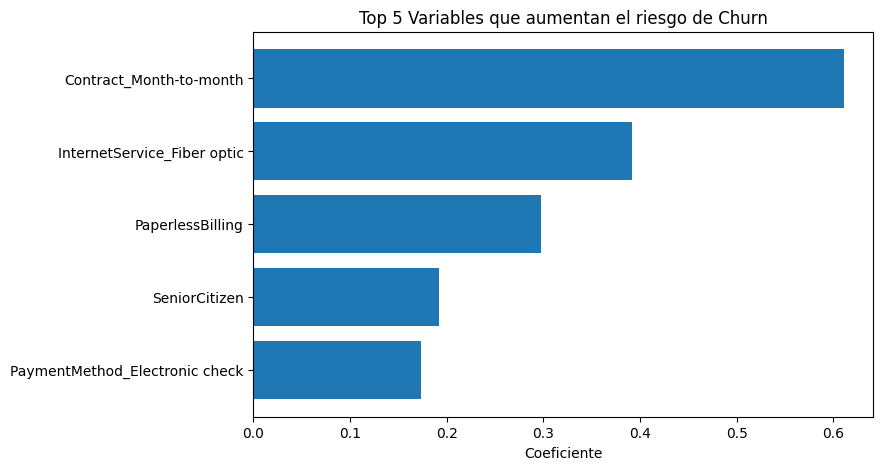

In [86]:
plt.figure(figsize=(8,5))

plt.barh(
    top_positivas["Variable"],
    top_positivas["Coeficiente"]
)

plt.title("Top 5 Variables que aumentan el riesgo de Churn")
plt.xlabel("Coeficiente")

plt.gca().invert_yaxis()

plt.show()

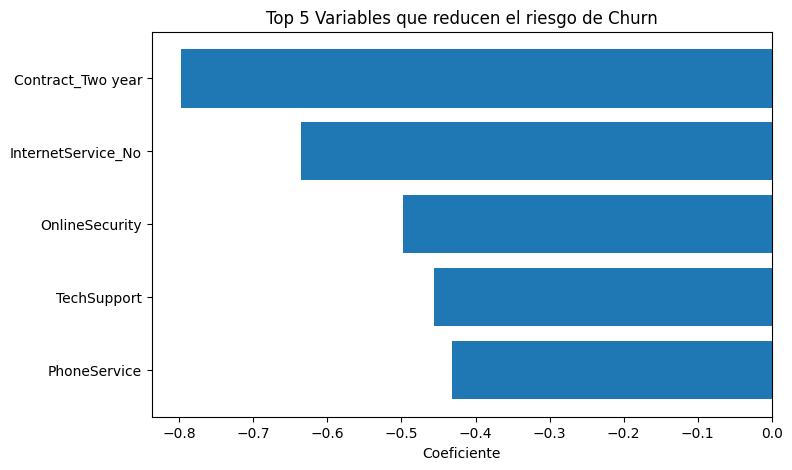

In [87]:
plt.figure(figsize=(8,5))

plt.barh(
    top_negativas["Variable"],
    top_negativas["Coeficiente"]
)

plt.title("Top 5 Variables que reducen el riesgo de Churn")
plt.xlabel("Coeficiente")

plt.gca().invert_yaxis()

plt.show()

#### Conclusion
Los coeficientes de la Regresión Logística confirman los resultados obtenidos durante el análisis exploratorio. Variables como el tipo de contrato, la antigüedad del cliente (tenure), el tipo de servicio de Internet y el soporte técnico fueron las que ejercieron mayor influencia sobre la predicción del modelo. En particular, los contratos de largo plazo y una mayor permanencia en la empresa reducen significativamente el riesgo de abandono, mientras que determinadas características, como el servicio de fibra óptica y los cargos mensuales elevados, incrementan la probabilidad de churn. Estos hallazgos permiten identificar los principales factores asociados a la retención y pérdida de clientes.

In [89]:
customer_df.to_csv("../data/processed/customer_churn_clean.csv",
    index=False
)

In [90]:
# Data Set para power BI

coeficientes = pd.DataFrame({
    "Variable": x_train.columns,
    "Coeficiente": modelo_lr.coef_[0]
})

coeficientes["Importancia"] = coeficientes["Coeficiente"].abs()

coeficientes = coeficientes.sort_values(
    "Importancia",
    ascending=False
)

coeficientes_top10 = coeficientes.head(10)

coeficientes_top10.to_csv("../data/processed/feature_importance_top10.csv", index=False)